#### Current comet issue -> Why we are doing this manually:

- The problem we are experiencing is:
- If you re-framed so much that the comet would be off the edge when the images are all registered to one common frame, those subs simply cannot contribute to a single comet stack. No amount of cross-correlation can “bring back” data that never hit the sensor
- So when we run the comet alignment function in pixinsgiht, which requires registered reference frames, we experience the problem that the comet is out of the field of view

### Plan for aligning comet:


1. Load all images into memory (or loop over them).
2. For each image:
3. Find the comet position (centroid or brightest pixel).
3. Pick one frame as reference, get its comet position.
4. Compute Δx,Δy shifts for every frame.
5. Use a shift/warp function (no wrapping) to translate each frame.
6. Stack the shifted frames with np.nanmedian or np.nanmean.

#### Shifting:
- What we are doing when shifting is calculating the delta difference between a reference image's center and another images center
- For us we chose a reference file with a specific comet pixel value and center, and so we calculate the pixel differences to all subsequent comet file centers
- When we shift:
    - Stuff that used to be near the top moves outside the top of the image → those pixels are lost.
    - Stuff that used to be near the left moves left out of frame.
    - New empty space appears at the bottom and the left, which we fill with NaN.
    - So after shifting:
    - Top/right parts of the array are filled with “real” data from many frames.
    - Bottom/left bands have NaNs for every frame except the reference image.

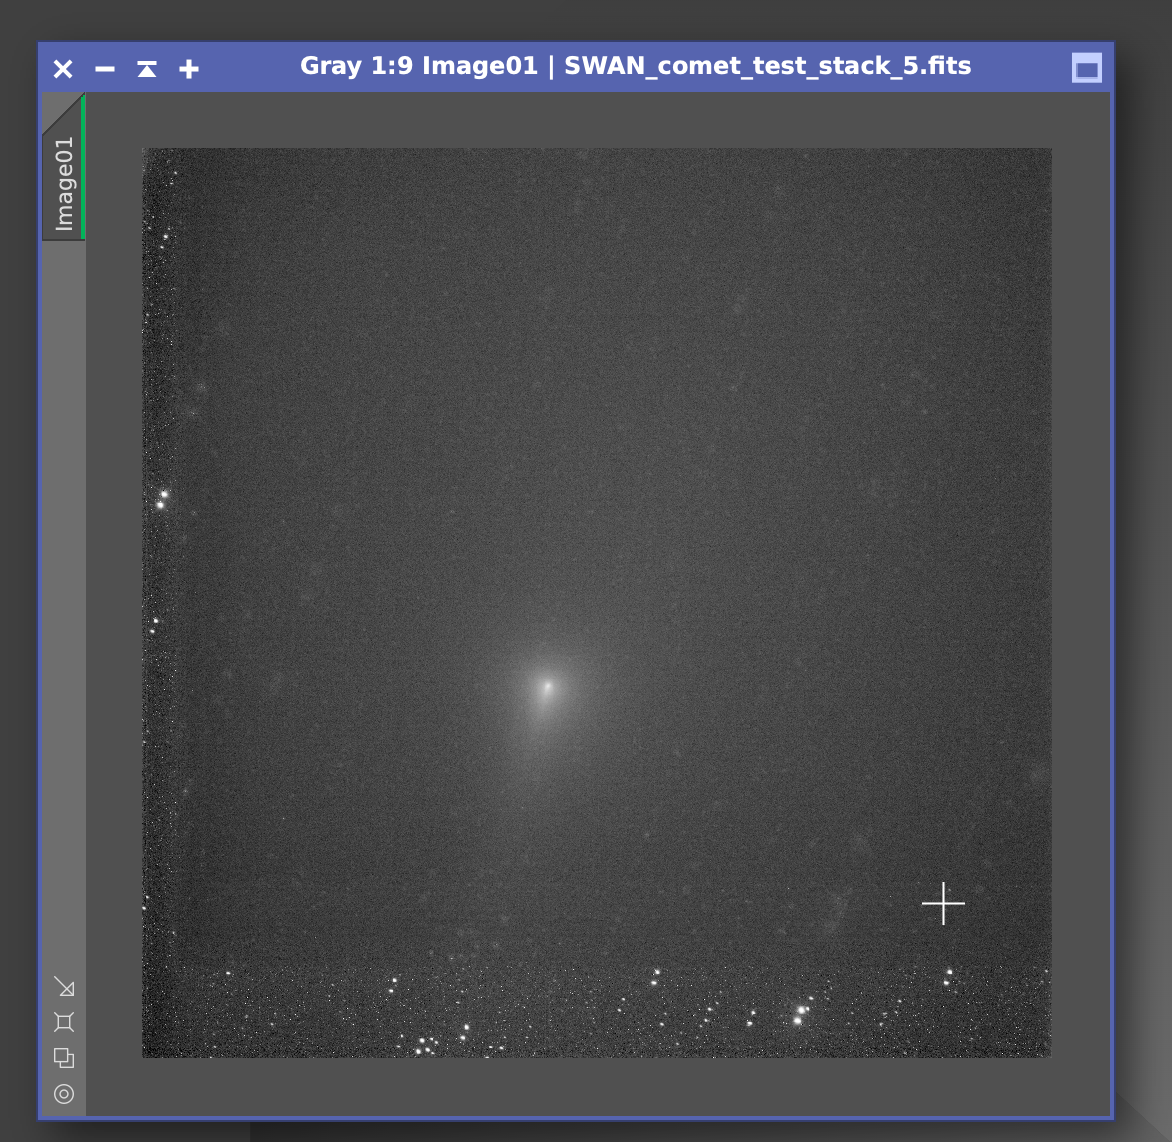

#### We will run this test with 5 images from sauron/usoimages/27OCT2025 directory - swan comet

Files:
- SWAN_R_300_2025_00000-37716.fits (reference file)
    - Flux value: 2535
    - Pixel position: x = 1828.25, y = 2423.75
- SWAN_R_300_2025_00000-37719.fits
    - Flux value: 2568
    - Pixel position: x = 1810, y = 2469.75
- SWAN_R_300_2025_00000-37742.fits
    - Flux value: 2552
    - Pixel position: x = 1675.5, y= 2833.25
- SWAN_R_300_2025_00000-37749.fits
    - Flux value:  2519
    - Pixel position: x = 1637.25, y = 2947.25
- SWAN_R_300_2025_00000-37766.fits
    - Flux value: 2537
    - Pixel position: x = 1546.5, y = 3218

### HDU Lists in astropy:
https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList

HDU list class. This is the top-level FITS object. When a FITS file is opened, a HDUList object is returned.
- Inside the primary HDU, there are two main parts:
- .header → a bunch of keywords (EXPTIME, FILTER, DATE-OBS, etc.)
- .data → the actual 2D array of pixel values

```python
data = hdul[0].data.astype(float)
hdul[0].data is a NumPy array that holds your image:
``` 
- Shape like (ny, nx) = (rows, columns)
- Each element is a pixel intensity (ADU or electrons)

header is a special Astropy object that acts like a dictionary of metadata.
- Like the fitsheader in the terminal with all the metadata -> we save it to output it to the new file later

In [5]:
def load_fits(filename):
    with fits.open(filename) as hdul: #When a FITS file is opened, a HDUList object is returned.

        data = hdul[0].data.astype(float)
        hdr = hdul[0].header
    return data, hdr

x, y = load_fits(files[0])
print(x)
x.shape
#FITS image is 4096 x 4096 pixel (as expected), and loaded into a 2D numpy array float
# Each number = pixel value from your CCD, probably in ADU (Analog-to-Digital Units).x

[[2058. 2050. 2034. ... 2164. 2180. 2159.]
 [2082. 2051. 2060. ... 2120. 2116. 2104.]
 [2074. 2039. 2036. ... 2068. 2091. 2095.]
 ...
 [2002. 2027. 2054. ... 2044. 2049. 2032.]
 [2029. 2035. 2031. ... 2042. 2041. 2033.]
 [2029. 2029. 2030. ... 2039. 2028. 2052.]]


(4096, 4096)

In [6]:
import numpy as np
from astropy.io import fits
# Documentation: https://docs.astropy.org/en/stable/io/fits/index.html
from scipy.ndimage import shift as nd_shift
# shift is a function that can translate an image by a fractional number of pixels
import os

directory = "/Users/alexkauffman/Desktop/Thunderbird South/Thunderbird_Astrophotography/SWAN"

files = [
    os.path.join(directory, "SWAN_R_300_2025_00000-37716.fits"),  # reference
    os.path.join(directory, "SWAN_R_300_2025_00000-37719.fits"),
    os.path.join(directory, "SWAN_R_300_2025_00000-37742.fits"),
    os.path.join(directory, "SWAN_R_300_2025_00000-37749.fits"),
    os.path.join(directory, "SWAN_R_300_2025_00000-37766.fits"),
]

# Dictionary mapping each file → the comet coordinates you measured in DS9.
# IMPORTANT: order is (y, x) to match numpy indexing [y, x]
# NumPy arrays are always accessed as array[y, x] (row first, column second).

positions_yx = {
    os.path.join(directory, "SWAN_R_300_2025_00000-37716.fits"): (2423.75, 1828.25), # -> row 2423.75, column 1828.25
    os.path.join(directory, "SWAN_R_300_2025_00000-37719.fits"): (2469.75, 1810.00),
    os.path.join(directory, "SWAN_R_300_2025_00000-37742.fits"): (2833.25, 1675.50),
    os.path.join(directory, "SWAN_R_300_2025_00000-37749.fits"): (2947.25, 1637.25),
    os.path.join(directory, "SWAN_R_300_2025_00000-37766.fits"): (3218.00, 1546.50),
}


# Reference position (file 37716)
ref_file = files[0]
y_ref, x_ref = positions_yx[ref_file] #take values from the ref_file

# Function to load and shift an image 
# When we open a file, we must close it to
# For example:
#hdul = fits.open(filename)
#data = hdul[0].data
#hdr = hdul[0].header
# ... use data ...
#hdul.close()   # MUST be remembered manually!
#This works, but: If you forget to call .close(), the file stays open. If an error occurs before close(), the file also stays open. Gives problems in larger FITS files etc...
# Using with ... as ...: ensures the FITS file is automatically closed, even if an error happens. It’s safer, prevents memory leaks,
# standard “best practice” in Python for working with files.

def load_fits(filename):
    with fits.open(filename) as hdul:
        data = hdul[0].data.astype(float)
        hdr = hdul[0].header
    return data, hdr

def shift_image(data, dy, dx, order=3):
    """
    Shift image by (dy, dx) pixels.
    mode='constant', cval=np.nan ensures no wrap-around.
    Heres what nd_shift does: Takes an image array (your data) -> Moves it by: 
    dy pixels in the vertical direction (rows), 
    dx pixels in the horizontal direction (columns).
    mode="constant", cval=np.nan means: When part of the image shifts “off” the edge, don’t wrap it around. Fill the new empty border pixels with cval = np.nan.

    So the function will return:
    same shape as data, but all the original pixels repositioned by (dy, dx), and new border regions are NaN. Then our wrapper shift_image just returns that array.
    """
    
    return nd_shift(data, shift=(dy, dx), order=order, mode="constant", cval=np.nan,)

# Apply shifts & collect shifted images
shifted_imgs = [] #To collect all the data (hdul component) arrays of the shifted images
hdr0 = None # will store the header from the first file we load (so we can re-use it when writing out the final FITS stack).

for fname in files:
    data, hdr = load_fits(fname)
    if hdr0 is None:
        hdr0 = hdr  # save header from first file

    y, x = positions_yx[fname]

    dy = y_ref - y
    dx = x_ref - x
    print(f"{fname}: dy = {dy:.2f}, dx = {dx:.2f}")

    shifted = shift_image(data, dy, dx)
    shifted_imgs.append(shifted) #After the loop, shifted_imgs is a list of 5 arrays, each same shape as the original images but aligned on the comet.

shifted_imgs = np.array(shifted_imgs)
#shifted_imgs.shape = (5, 4096, 4096)
# dim0 -> which of the 5 files we are using
# dim1 -> row(y)
# dim2 -> column(x)

# Stack with nanmedian to ignore empty edges 
# We use median and not average because median is better at getting rid of outliers (cosimic rays, hot pixels, if we were calibrated) than average does 
# This is bc median selects the middle of the distribution, but average takes into account all values, so it is more affected by the outliers we want to get rid of
# It takes the median of the 5 stacked images ignoring any NaN values.
# If a pixel is NaN in some frames (because they were shifted off the edge), np.nanmedian drops the NaNs and computes the median using the remaining real pixels.
# https://numpy.org/doc/stable/reference/generated/numpy.nanmedian.html
comet_stack = np.nanmedian(shifted_imgs, axis=0)

# Save result 
hdu = fits.PrimaryHDU(comet_stack, header=hdr0)
hdu.writeto("SWAN_comet_test_stack_5.fits", overwrite=True)

print("Saved SWAN_comet_test_stack_5.fits")

/Users/alexkauffman/Desktop/Thunderbird South/Thunderbird_Astrophotography/SWAN/SWAN_R_300_2025_00000-37716.fits: dy = 0.00, dx = 0.00
/Users/alexkauffman/Desktop/Thunderbird South/Thunderbird_Astrophotography/SWAN/SWAN_R_300_2025_00000-37719.fits: dy = -46.00, dx = 18.25
/Users/alexkauffman/Desktop/Thunderbird South/Thunderbird_Astrophotography/SWAN/SWAN_R_300_2025_00000-37742.fits: dy = -409.50, dx = 152.75
/Users/alexkauffman/Desktop/Thunderbird South/Thunderbird_Astrophotography/SWAN/SWAN_R_300_2025_00000-37749.fits: dy = -523.50, dx = 191.00
/Users/alexkauffman/Desktop/Thunderbird South/Thunderbird_Astrophotography/SWAN/SWAN_R_300_2025_00000-37766.fits: dy = -794.25, dx = 281.75
Saved SWAN_comet_test_stack_5.fits


In [7]:
import numpy as np
from scipy.ndimage import median_filter

def comet_peak_roi(data, y0, x0, half_size=150, med_size=5):
    """
    Find comet center by:
      1. cutting out an ROI around (y0, x0)
      2. median-smoothing the ROI
      3. taking the brightest pixel in the smoothed ROI

    Parameters
    ----------
    data : 2D numpy array
        Image pixels.
    y0, x0 : float
        Rough guess of comet position (e.g. from DS9, same for all frames in a set).
    half_size : int
        Half-width of ROI in pixels. ROI ~ [y0±half_size, x0±half_size].
    med_size : int
        Kernel size for median filter (odd integer: 3,5,7,...).

    Returns
    -------
    cy, cx : float
        Estimated comet center in FULL image coordinates (y, x).
    """
    ny, nx = data.shape

    # 1. ROI bounds, clipped to image
    y1 = max(0, int(y0 - half_size))
    y2 = min(ny, int(y0 + half_size))
    x1 = max(0, int(x0 - half_size))
    x2 = min(nx, int(x0 + half_size))

    sub = data[y1:y2, x1:x2]

    # 2. Median smoothing inside ROI
    sub_smooth = median_filter(sub, size=med_size)

    # 3. Max pixel in smoothed ROI
    idx = np.unravel_index(np.argmax(sub_smooth), sub_smooth.shape)
    y_local, x_local = idx

    # convert back to full-image coordinates
    cy = y1 + y_local
    cx = x1 + x_local

    return float(cy), float(cx)

In [11]:
data, hdr = load_fits(os.path.join(directory, "SWAN_R_300_2025_00000-37716.fits"))
# your DS9 measurement as an initial guess
y_guess = 2423.75
x_guess = 1828.25

cy, cx = comet_peak_roi(data, y_guess, x_guess,
                        half_size=200,   # big enough to cover comet motion
                        med_size=5)      # 5x5 median kernel

print("DS9 guess:   ", y_guess, x_guess)
print("Python peak: ", cy, cx)

DS9 guess:    2423.75 1828.25
Python peak:  2423.0 1828.0


### Processing SWAN_COMET Data (Manual version)

### REF: swanComet_R_299_2025_00000-37665.fits

#### R-band

swanComet_R_299_2025_00000-37665.fits
- x = 1760.75, y = 3100.75
swanComet_R_299_2025_00000-37666.fits
- x = 1756.25, y = 3114.75
swanComet_R_299_2025_00000-37667.fits
- x = 1751.75, y = 3134.25
swanComet_R_299_2025_00000-37668.fits
- x = 1745.75, y = 3151.25
swanComet_R_299_2025_00000-37669.fits
- x = 1742.75, y = 3160.25
swanComet_R_299_2025_00000-37670.fits
- x = 1734.75, y = 3184
swanComet_R_299_2025_00000-37671.fits
- x = 1730.25, y = 3201.25
swanComet_R_299_2025_00000-37672.fits
- x = 1722.75, y = 3218.25
swanComet_R_299_2025_00000-37673.fits
- x = 1720.75, y = 3321.25
swanComet_R_299_2025_00000-37674.fits
- x = 1711, y = 3255
swanComet_R_299_2025_00000-37675.fits
- x = 1706, 3270.25
swanComet_R_299_2025_00000-37676.fits
- x = 1700.5, y = 3287
swanComet_R_299_2025_00000-37677.fits
- x = 1694.25, y = 3308
swanComet_R_299_2025_00000-37678.fits
- x = 1691, y = 3323.25
swanComet_R_299_2025_00000-37679.fits
- x = 1684.5, y = 3336
swanComet_R_299_2025_00000-37680.fits
- x = 1679.5, y = 3359.25
swanComet_R_299_2025_00000-37681.fits
- x = 1674, y = 3374
swanComet_R_299_2025_00000-37682.fits
- x = 1669.25, y = 3389
swanComet_R_299_2025_00000-37683.fits
- x = 2524, y = 3408.75
swanComet_R_299_2025_00000-37684.fits
- x = 1656.75, y = 3426.25
swanComet_R_299_2025_00000-37685.fits
- x = 1650.75, y = 3443.25

#### V-band

swanComet_V_299_2025_00000-37606.fits
- NOTHING
swanComet_V_299_2025_00000-37607.fits
- NOTHING
swanComet_V_299_2025_00000-37608.fits
- x = 1843, y = 2481
swanComet_V_299_2025_00000-37609.fits
- x = 1826, y = 2501
swanComet_V_299_2025_00000-37610.fits
- x = 1832.5, y = 2512
swanComet_V_299_2025_00000-37611.fits
- x = 1828.5, 2532.5
swanComet_V_299_2025_00000-37612.fits
- x = 2349, y = 2555
swanComet_V_299_2025_00000-37613.fits
- x = 1818, y = 2570.5
swanComet_V_299_2025_00000-37614.fits
- x = 1810, y = 2585.5
swanComet_V_299_2025_00000-37615.fits
- x = 1800, y = 2606.5
swanComet_V_299_2025_00000-37616.fits
- x = 1791.5, y = 2617
swanComet_V_299_2025_00000-37617.fits
- x = 1790.5, y = 2638
swanComet_V_299_2025_00000-37618.fits
- x = 1785, y = 2655
swanComet_V_299_2025_00000-37619.fits
- x = 1773.5, y = 2666
swanComet_V_299_2025_00000-37620.fits
- x = 1765.5, y = 2687.5
swanComet_V_299_2025_00000-37621.fits
- x = 1759, y = 2704.5
swanComet_V_299_2025_00000-37622.fits
- x = 1747.5, y = 2725.5
swanComet_V_299_2025_00000-37623.fits
- x = 1744, y = 2743
swanComet_V_299_2025_00000-37624.fits
- x = 1740, y = 2752.5
swanComet_V_299_2025_00000-37625.fits
- x = 1763.5, y = 2771.5
swanComet_V_299_2025_00000-37626.fits
- x = 1724, y = 2790
swanComet_V_299_2025_00000-37627.fits
- x = 1718, y = 2814
swanComet_V_299_2025_00000-37628.fits
- x = 1709, 2825.5
swanComet_V_299_2025_00000-37629.fits
- x = 1705, y = 2842.5
swanComet_V_299_2025_00000-37630.fits
- x = 1697.5, y = 2860
swanComet_V_299_2025_00000-37631.fits
- x = 1691.5, y = 2833.5
swanComet_V_299_2025_00000-37632.fits
- x = 1689.5, y = 2892.5
swanComet_V_299_2025_00000-37633.fits
- x = 1681, y = 2915
swanComet_V_299_2025_00000-37634.fits
- x = 1677.5, y = 2930.5
swanComet_V_299_2025_00000-37635.fits
- x = 1668, y = 2948.5
swanComet_V_299_2025_00000-37636.fits
- x = 1659.5, y = 2969
swanComet_V_299_2025_00000-37637.fits
- x = 1656, y = 2985.5
swanComet_V_299_2025_00000-37638.fits
- x = 1646, y = 2995
swanComet_V_299_2025_00000-37639.fits
- x = 1644.5, y = 3016
swanComet_V_299_2025_00000-37640.fits
- x = 1635.5, y = 3083.5
swanComet_V_299_2025_00000-37641.fits
- x = 1630.5, y = 3048.5
swanComet_V_299_2025_00000-37642.fits
- x = 1624.5, y = 3066.5
swanComet_V_299_2025_00000-37643.fits
- x = 1615, y = 3085.5
swanComet_V_299_2025_00000-37644.fits
- x = 1610, y = 3100
swanComet_V_299_2025_00000-37645.fits
- x = 1609.5, y = 3101.5
swanComet_V_299_2025_00000-37646.fits
- x = 1602, y = 3127.5
swanComet_V_299_2025_00000-37647.fits
- x = 1593.5, y = 3151
swanComet_V_299_2025_00000-37648.fits
- x = 1589.5, 3168.5
swanComet_V_299_2025_00000-37649.fits
- x = 1588, y = 3169
swanComet_V_299_2025_00000-37650.fits
- x = 1584.5, y = 3184.5
swanComet_V_299_2025_00000-37660.fits
- x = 1434.5, y = 3615.5
swanComet_V_299_2025_00000-37661.fits
- x = 1417.5, y = 3668
swanComet_V_299_2025_00000-37662.fits
- x = 1417, y = 2680.5

#### B-band

swanComet_B_299_2025_00000-37686.fits
- x = 1668, y = 2937.25
swanComet_B_299_2025_00000-37687.fits
- x = 1664.5, y = 2956.75
swanComet_B_299_2025_00000-37688.fits
- x = 1657, y = 2975.75
swanComet_B_299_2025_00000-37689.fits
- x = 1654.25, y = 2990.75
swanComet_B_299_2025_00000-37690.fits
- x = 1648.5, y = 3005.5
swanComet_B_299_2025_00000-37691.fits
- x = 1643.5, y = 3023.5
swanComet_B_299_2025_00000-37692.fits
- x = 1638, y = 3041
swanComet_B_299_2025_00000-37693.fits
- x = 1633, y = 3057.75
swanComet_B_299_2025_00000-37694.fits
- x = 1627.25, y = 3076.5
swanComet_B_299_2025_00000-37695.fits
- x = 1620.25, y = 3095
swanComet_B_299_2025_00000-37696.fits
- x = 1616.5, y = 3109.25
swanComet_B_299_2025_00000-37697.fits
- x = 1610.25, y = 3122.75
swanComet_B_299_2025_00000-37698.fits
- x = 1602.75, y = 3146
swanComet_B_299_2025_00000-37699.fits
- x = 1597.5, y = 3165.25
swanComet_B_299_2025_00000-37700.fits
- x = 1593.25, y = 3177.25
swanComet_B_299_2025_00000-37701.fits
- x = 1586.75, 3198.75
swanComet_B_299_2025_00000-37702.fits
- x = 1578.75, y = 3213.75
swanComet_B_299_2025_00000-37703.fits
- x = 1573.75, 3229.5
swanComet_B_299_2025_00000-37704.fits
- x = 1568, y = 3250.5
swanComet_B_299_2025_00000-37705.fits
- x = 1562.75, x = 3265
swanComet_B_299_2025_00000-37706.fits
- x = 1558.5, y = 3282.25
swanComet_B_299_2025_00000-37707.fits
- x = 1553, y = 3229.75
swanComet_B_299_2025_00000-37708.fits
- x = 1547.25, y = 3319.5
swanComet_B_299_2025_00000-37709.fits
- x = 1541.25, y = 3336
swanComet_B_299_2025_00000-37710.fits
- x = 1525.25, 3349.75

In [13]:
import numpy as np
from astropy.io import fits
from scipy.ndimage import shift as nd_shift
import os

# -------------------------------------------------
# 1. Directory & file list
# -------------------------------------------------

directory = "/Users/alexkauffman/Desktop/swan_night2"

files = [
    os.path.join(directory, "swanComet_R_299_2025_00000-37665.fits"),  # reference
    os.path.join(directory, "swanComet_R_299_2025_00000-37666.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37667.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37668.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37669.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37670.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37671.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37672.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37673.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37674.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37675.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37676.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37677.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37678.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37680.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37681.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37682.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37683.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37684.fits"),
    os.path.join(directory, "swanComet_R_299_2025_00000-37685.fits"),
]

# -------------------------------------------------
# 2. Measured comet positions from DS9 (y, x)
# -------------------------------------------------

positions_yx = {
    os.path.join(directory, "swanComet_R_299_2025_00000-37665.fits"): (3102.00, 1760.50),
    os.path.join(directory, "swanComet_R_299_2025_00000-37666.fits"): (3114.75, 1757.25),
    os.path.join(directory, "swanComet_R_299_2025_00000-37667.fits"): (3133.50, 1752.00),
    os.path.join(directory, "swanComet_R_299_2025_00000-37668.fits"): (3153.00, 1743.50),
    os.path.join(directory, "swanComet_R_299_2025_00000-37669.fits"): (3163.25, 1743.00),
    os.path.join(directory, "swanComet_R_299_2025_00000-37670.fits"): (3184.25, 1734.50),
    os.path.join(directory, "swanComet_R_299_2025_00000-37671.fits"): (3194.00, 1732.25),
    os.path.join(directory, "swanComet_R_299_2025_00000-37672.fits"): (3217.50, 1723.75),
    os.path.join(directory, "swanComet_R_299_2025_00000-37673.fits"): (3233.75, 1718.25),
    os.path.join(directory, "swanComet_R_299_2025_00000-37674.fits"): (3254.50, 1712.00),
    os.path.join(directory, "swanComet_R_299_2025_00000-37675.fits"): (3271.75, 1706.00),
    os.path.join(directory, "swanComet_R_299_2025_00000-37676.fits"): (3308.75, 1695.00),
    os.path.join(directory, "swanComet_R_299_2025_00000-37677.fits"): (3322.50, 1690.25),
    os.path.join(directory, "swanComet_R_299_2025_00000-37678.fits"): (3337.75, 1684.25),
    os.path.join(directory, "swanComet_R_299_2025_00000-37680.fits"): (3356.25, 1679.25),
    os.path.join(directory, "swanComet_R_299_2025_00000-37681.fits"): (3372.75, 1677.25),
    os.path.join(directory, "swanComet_R_299_2025_00000-37682.fits"): (3392.25, 1697.75),
    os.path.join(directory, "swanComet_R_299_2025_00000-37683.fits"): (3406.00, 1692.74),
    os.path.join(directory, "swanComet_R_299_2025_00000-37684.fits"): (3422.00, 1660.25),
    os.path.join(directory, "swanComet_R_299_2025_00000-37685.fits"): (3439.50, 1652.25),
}

# -------------------------------------------------
# 3. Reference position (use first file)
# -------------------------------------------------

ref_file = files[0]
y_ref, x_ref = positions_yx[ref_file]

# -------------------------------------------------
# 4. FITS helpers
# -------------------------------------------------

def load_fits(filename):
    with fits.open(filename) as hdul:
        data = hdul[0].data.astype(float)
        hdr = hdul[0].header
    return data, hdr

def shift_image(data, dy, dx, order=3):
    """
    Shift image by (dy, dx) pixels.
    dy: rows (vertical), dx: columns (horizontal).
    New pixels created at the borders are set to NaN.
    """
    return nd_shift(
        data,
        shift=(dy, dx),
        order=order,
        mode="constant",
        cval=np.nan,
    )

# -------------------------------------------------
# 5. Apply shifts & median stack
# -------------------------------------------------

shifted_imgs = []
hdr0 = None

for fname in files:
    data, hdr = load_fits(fname)
    if hdr0 is None:
        hdr0 = hdr

    y, x = positions_yx[fname]
    dy = y_ref - y
    dx = x_ref - x
    print(f"{os.path.basename(fname)}: dy = {dy:.2f}, dx = {dx:.2f}")

    shifted = shift_image(data, dy, dx)
    shifted_imgs.append(shifted)

shifted_imgs = np.array(shifted_imgs)

print("Shifted stack shape:", shifted_imgs.shape)

# Median combine along the stack axis, ignoring NaNs at edges
comet_stack = np.nanmedian(shifted_imgs, axis=0)

# -------------------------------------------------
# 6. Save result
# -------------------------------------------------

outname = os.path.join(directory, "swanComet_R_299_2025_comet_stack_20.fits")
hdu = fits.PrimaryHDU(comet_stack, header=hdr0)
hdu.writeto(outname, overwrite=True)

print("Saved", outname)

swanComet_R_299_2025_00000-37665.fits: dy = 0.00, dx = 0.00
swanComet_R_299_2025_00000-37666.fits: dy = -12.75, dx = 3.25
swanComet_R_299_2025_00000-37667.fits: dy = -31.50, dx = 8.50
swanComet_R_299_2025_00000-37668.fits: dy = -51.00, dx = 17.00
swanComet_R_299_2025_00000-37669.fits: dy = -61.25, dx = 17.50
swanComet_R_299_2025_00000-37670.fits: dy = -82.25, dx = 26.00
swanComet_R_299_2025_00000-37671.fits: dy = -92.00, dx = 28.25
swanComet_R_299_2025_00000-37672.fits: dy = -115.50, dx = 36.75
swanComet_R_299_2025_00000-37673.fits: dy = -131.75, dx = 42.25
swanComet_R_299_2025_00000-37674.fits: dy = -152.50, dx = 48.50
swanComet_R_299_2025_00000-37675.fits: dy = -169.75, dx = 54.50
swanComet_R_299_2025_00000-37676.fits: dy = -206.75, dx = 65.50
swanComet_R_299_2025_00000-37677.fits: dy = -220.50, dx = 70.25
swanComet_R_299_2025_00000-37678.fits: dy = -235.75, dx = 76.25
swanComet_R_299_2025_00000-37680.fits: dy = -254.25, dx = 81.25
swanComet_R_299_2025_00000-37681.fits: dy = -270.75,

In [8]:
import os
import numpy as np
from astropy.io import fits
from scipy.ndimage import shift as nd_shift

directory = "/Users/alexkauffman/Desktop/swan_night2/calibrated"
OUT_DIR = directory
TRY_READ_XISF = True


# If we have FITS files, it extracts a numpy array of the data ("data" variable)
# Pulls image from Hdul0
def load_fits(filename):
    with fits.open(filename) as hdul:
        data = hdul[0].data.astype(np.float32)
        hdr = hdul[0].header
    return data, hdr

# If we have XISF files, it extracts a numpy array of the data ("data" variable)
def load_xisf(filename): # If we don't have FITS files, and we have XISF load module xisf that deals with XISF files
        import xisf

    x = xisf.XISF(filename)
    data = x.read_image(0).astype(np.float32)
    return data, None

# Loading images -> will load fits if we have fits, will load XISF if we have those
# Whichever we have (fits or xisf) it doesn't matter because it will run the function that gets us back a numpy array
def load_image(filename):
    ext = os.path.splitext(filename)[1].lower()
    if ext == ".fits":
        return load_fits(filename)
    if ext == ".xisf":
        if not TRY_READ_XISF:
            raise RuntimeError("XISF encountered but TRY_READ_XISF=False")
        return load_xisf(filename)
    raise ValueError(f"Unsupported file: {filename}")


#Image shifting function
def shift_image(data, dy, dx, order=3):
    """
    Shift image in last two axes only.
    Works for 2D or higher-dim arrays.
    """
    data = np.asarray(data)
    data = np.squeeze(data) #Squeeze removes useless dimensions ie: (1,4096,4096) -> (4096,4096).

    if data.ndim < 2:
        raise ValueError(f"Invalid data shape: {data.shape}")

    #Fail safe, sometimes we get a weird dimension mismatch ie. sometimes we get (1,4096,4096)
    #If the data is 2D, shift_vec becomes [dy, dx].
    # If the data is 3D (rare but possible), it becomes [0, dy, dx].
    # So we always shift only the last two axes (y, x).
    shift_vec = [0.0] * data.ndim
    shift_vec[-2] = dy
    shift_vec[-1] = dx

    return nd_shift(
        data,
        shift=tuple(shift_vec),
        order=order,
        mode="constant",
        cval=np.nan,
        prefilter=True,
    )


def resolve_calibrated_path(directory, base_stem):
    candidates = [
        os.path.join(directory, f"{base_stem}_c.fits"),
        os.path.join(directory, f"{base_stem}_c.xisf"),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    return None

# DS9 comet positions (x, y)
R_positions_xy = {
    "swanComet_R_299_2025_00000-37665": (1760.75, 3100.75),
    "swanComet_R_299_2025_00000-37666": (1756.25, 3114.75),
    "swanComet_R_299_2025_00000-37667": (1751.75, 3134.25),
    "swanComet_R_299_2025_00000-37668": (1745.75, 3151.25),
    "swanComet_R_299_2025_00000-37669": (1742.75, 3160.25),
    "swanComet_R_299_2025_00000-37670": (1734.75, 3184.00),
    "swanComet_R_299_2025_00000-37671": (1730.25, 3201.25),
    "swanComet_R_299_2025_00000-37672": (1722.75, 3218.25),
    "swanComet_R_299_2025_00000-37673": (1720.75, 3321.25),
    "swanComet_R_299_2025_00000-37674": (1711.00, 3255.00),
    "swanComet_R_299_2025_00000-37675": (1706.00, 3270.25),
    "swanComet_R_299_2025_00000-37676": (1700.50, 3287.00),
    "swanComet_R_299_2025_00000-37677": (1694.25, 3308.00),
    "swanComet_R_299_2025_00000-37678": (1691.00, 3323.25),
    "swanComet_R_299_2025_00000-37679": (1684.50, 3336.00),
    "swanComet_R_299_2025_00000-37680": (1679.50, 3359.25),
    "swanComet_R_299_2025_00000-37681": (1674.00, 3374.00),
    "swanComet_R_299_2025_00000-37682": (1669.25, 3389.00),
    "swanComet_R_299_2025_00000-37684": (1656.75, 3426.25),
    "swanComet_R_299_2025_00000-37685": (1650.75, 3443.25),
}

V_positions_xy = {
    "swanComet_V_299_2025_00000-37606": None,
    "swanComet_V_299_2025_00000-37607": None,
    "swanComet_V_299_2025_00000-37608": (1843.00, 2481.00),
    "swanComet_V_299_2025_00000-37609": (1826.00, 2501.00),
    "swanComet_V_299_2025_00000-37610": (1832.50, 2512.00),
    "swanComet_V_299_2025_00000-37611": (1828.50, 2532.50),
    "swanComet_V_299_2025_00000-37613": (1818.00, 2570.50),
    "swanComet_V_299_2025_00000-37614": (1810.00, 2585.50),
    "swanComet_V_299_2025_00000-37615": (1800.00, 2606.50),
    "swanComet_V_299_2025_00000-37616": (1791.50, 2617.00),
    "swanComet_V_299_2025_00000-37617": (1790.50, 2638.00),
    "swanComet_V_299_2025_00000-37618": (1785.00, 2655.00),
    "swanComet_V_299_2025_00000-37619": (1773.50, 2666.00),
    "swanComet_V_299_2025_00000-37620": (1765.50, 2687.50),
    "swanComet_V_299_2025_00000-37621": (1759.00, 2704.50),
    "swanComet_V_299_2025_00000-37622": (1747.50, 2725.50),
    "swanComet_V_299_2025_00000-37623": (1744.00, 2743.00),
    "swanComet_V_299_2025_00000-37624": (1740.00, 2752.50),
    "swanComet_V_299_2025_00000-37625": (1763.50, 2771.50),
    "swanComet_V_299_2025_00000-37626": (1724.00, 2790.00),
    "swanComet_V_299_2025_00000-37627": (1718.00, 2814.00),
    "swanComet_V_299_2025_00000-37628": (1709.00, 2825.50),
    "swanComet_V_299_2025_00000-37629": (1705.00, 2842.50),
    "swanComet_V_299_2025_00000-37630": (1697.50, 2860.00),
    "swanComet_V_299_2025_00000-37631": (1691.50, 2833.50),
    "swanComet_V_299_2025_00000-37632": (1689.50, 2892.50),
    "swanComet_V_299_2025_00000-37633": (1681.00, 2915.00),
    "swanComet_V_299_2025_00000-37634": (1677.50, 2930.50),
    "swanComet_V_299_2025_00000-37635": (1668.00, 2948.50),
    "swanComet_V_299_2025_00000-37636": (1659.50, 2969.00),
    "swanComet_V_299_2025_00000-37637": (1656.00, 2985.50),
    "swanComet_V_299_2025_00000-37638": (1646.00, 2995.00),
    "swanComet_V_299_2025_00000-37639": (1644.50, 3016.00),
    "swanComet_V_299_2025_00000-37640": (1635.50, 3083.50),
    "swanComet_V_299_2025_00000-37641": (1630.50, 3048.50),
    "swanComet_V_299_2025_00000-37642": (1624.50, 3066.50),
    "swanComet_V_299_2025_00000-37643": (1615.00, 3085.50),
    "swanComet_V_299_2025_00000-37644": (1610.00, 3100.00),
    "swanComet_V_299_2025_00000-37645": (1609.50, 3101.50),
    "swanComet_V_299_2025_00000-37646": (1602.00, 3127.50),
    "swanComet_V_299_2025_00000-37647": (1593.50, 3151.00),
    "swanComet_V_299_2025_00000-37648": (1589.50, 3168.50),
    "swanComet_V_299_2025_00000-37649": (1588.00, 3169.00),
    "swanComet_V_299_2025_00000-37650": (1584.50, 3184.50),
    "swanComet_V_299_2025_00000-37660": (1434.50, 3615.50),
    "swanComet_V_299_2025_00000-37661": (1417.50, 3668.00),
    "swanComet_V_299_2025_00000-37662": (1417.00, 2680.50),
}

B_positions_xy = {
    "swanComet_B_299_2025_00000-37686": (1668.00, 2937.25),
    "swanComet_B_299_2025_00000-37687": (1664.50, 2956.75),
    "swanComet_B_299_2025_00000-37688": (1657.00, 2975.75),
    "swanComet_B_299_2025_00000-37689": (1654.25, 2990.75),
    "swanComet_B_299_2025_00000-37690": (1648.50, 3005.50),
    "swanComet_B_299_2025_00000-37691": (1643.50, 3023.50),
    "swanComet_B_299_2025_00000-37692": (1638.00, 3041.00),
    "swanComet_B_299_2025_00000-37693": (1633.00, 3057.75),
    "swanComet_B_299_2025_00000-37694": (1627.25, 3076.50),
    "swanComet_B_299_2025_00000-37695": (1620.25, 3095.00),
    "swanComet_B_299_2025_00000-37696": (1616.50, 3109.25),
    "swanComet_B_299_2025_00000-37697": (1610.25, 3122.75),
    "swanComet_B_299_2025_00000-37698": (1602.75, 3146.00),
    "swanComet_B_299_2025_00000-37699": (1597.50, 3165.25),
    "swanComet_B_299_2025_00000-37700": (1593.25, 3177.25),
    "swanComet_B_299_2025_00000-37701": (1586.75, 3198.75),
    "swanComet_B_299_2025_00000-37702": (1578.75, 3213.75),
    "swanComet_B_299_2025_00000-37703": (1573.75, 3229.50),
    "swanComet_B_299_2025_00000-37704": (1568.00, 3250.50),
    "swanComet_B_299_2025_00000-37705": (1562.75, 3265.00),
    "swanComet_B_299_2025_00000-37706": (1558.50, 3282.25),
    "swanComet_B_299_2025_00000-37707": (1553.00, 3229.75),
    "swanComet_B_299_2025_00000-37708": (1547.25, 3319.50),
    "swanComet_B_299_2025_00000-37709": (1541.25, 3336.00),
    "swanComet_B_299_2025_00000-37710": (1525.25, 3349.75),
}

# Create dictionary called bands that has all of the manual comet inputs into it

BANDS = {"R": R_positions_xy, "V": V_positions_xy, "B": B_positions_xy}

# GLOBAL reference: use the R reference point (same pixel target for ALL bands)
# We want all stacks to place the comet at this exact (y,x).
# DS9 positions are (x,y) so convert to (y,x):

GLOBAL_REF_YX = (R_positions_xy["swanComet_R_299_2025_00000-37665"][1],
                 R_positions_xy["swanComet_R_299_2025_00000-37665"][0])

# stacking function
# 
def comet_stack_band(band_label, positions_xy_dict, global_ref_yx=None, order=3):
    items = []

    # positions_xy_dict is a dictionary containing all of our files. For ex:
    # positions_xy_dict = {
    # "swanComet_R_...-37665": (1760.75, 3100.75),
    # "swanComet_R_...-37666": (1756.25, 3114.75), etc... 

    for stem, xy in positions_xy_dict.items(): #Stem is the name of the file, xy is the tuple position
        if xy is None: #Some xy were none because they actually didn't contain the comet
            continue
        path = resolve_calibrated_path(directory, stem) #This function was to actually get the calibrated version of the files
        # Since origionally they are the ds9 uncalibrated versions
        if path is None:
            print(f"[{band_label}] Missing calibrated file: {stem}")
            continue

        x, y = xy
        items.append((path, (y, x)))  # store as (y,x) 
        # for example an item may look like: "/path/to/swanComet_R_...-37665_c.xisf", (3100.75, 1760.75))
        # and it is a list of these things

    if len(items) < 2:
        raise RuntimeError(f"[{band_label}] Not enough frames to stack")

    if global_ref_yx is not None:
        # If you pass global_ref_yx, every band aligns to the same pixel location (the R reference comet position)
        y_ref, x_ref = global_ref_yx
        print(f"\n[{band_label}] Using GLOBAL reference (y,x)=({y_ref:.2f},{x_ref:.2f})")
    else:
        # If no global reference is given, it uses the first available frame in that band as its reference.
        # That means V aligns to V’s first frame, B aligns to B’s first frame, etc...
        # Not good for RGB Alignment, but single frame alignment it would work
        ref_path, (y_ref, x_ref) = items[0]
        print(f"\n[{band_label}] Reference: {os.path.basename(ref_path)} at (y,x)=({y_ref:.2f},{x_ref:.2f})")

    shifted_imgs = [] #will hold all shifted images as arrays
    hdr0 = None

    for path, (y, x) in items:
        data, hdr = load_image(path) #opens FITS or XISF
        data_sq = np.squeeze(data) #removes extra axes, like (1,4096,4096) → (4096,4096)

        if hdr0 is None and hdr is not None:
            hdr0 = hdr

        # If the comet in this frame is at (y, x) but you want it at (y_ref, x_ref): you shift by the difference
        dy = y_ref - y
        dx = x_ref - x
        print(f"[{band_label}] {os.path.basename(path)} shape {data.shape} -> {data_sq.shape} | dy={dy:.2f}, dx={dx:.2f}")

        shifted_imgs.append(shift_image(data_sq, dy, dx, order=order))
        # This produces a shifted image where the comet is now at (y_ref, x_ref) for every frame

    stack = np.nanmedian(np.array(shifted_imgs), axis=0)
    # Creates a 3D array (N, height, width)
    # Takes the median for each pixel location across N frames
    #Ignores NaNs at borders (created by shifts)

    outname = os.path.join(OUT_DIR, f"swanComet_{band_label}_299_2025_comet_stack.fits")
    fits.PrimaryHDU(stack, header=hdr0).writeto(outname, overwrite=True)
    print(f"[{band_label}] Saved {outname}")

# Run all bands (aligned to GLOBAL_REF_YX)
if __name__ == "__main__":
    for band, posdict in BANDS.items():
        comet_stack_band(band, posdict, global_ref_yx=GLOBAL_REF_YX, order=3)


[R] Using GLOBAL reference (y,x)=(3100.75,1760.75)
[R] swanComet_R_299_2025_00000-37665_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=0.00, dx=0.00
[R] swanComet_R_299_2025_00000-37666_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=-14.00, dx=4.50
[R] swanComet_R_299_2025_00000-37667_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=-33.50, dx=9.00
[R] swanComet_R_299_2025_00000-37668_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=-50.50, dx=15.00
[R] swanComet_R_299_2025_00000-37669_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=-59.50, dx=18.00
[R] swanComet_R_299_2025_00000-37670_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=-83.25, dx=26.00
[R] swanComet_R_299_2025_00000-37671_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=-100.50, dx=30.50
[R] swanComet_R_299_2025_00000-37672_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=-117.50, dx=38.00
[R] swanComet_R_299_2025_00000-37673_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=-220.50, dx=40.00
[R] swanComet_

/var/folders/n9/cy4kn3_x0n797qgp208h7g2m0000gn/T/ipykernel_83517/3545175528.py:242: RuntimeWarning: All-NaN slice encountered
  stack = np.nanmedian(np.array(shifted_imgs), axis=0)


[V] Saved /Users/alexkauffman/Desktop/swan_night2/calibrated/swanComet_V_299_2025_comet_stack.fits

[B] Using GLOBAL reference (y,x)=(3100.75,1760.75)
[B] swanComet_B_299_2025_00000-37686_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=163.50, dx=92.75
[B] swanComet_B_299_2025_00000-37687_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=144.00, dx=96.25
[B] swanComet_B_299_2025_00000-37688_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=125.00, dx=103.75
[B] swanComet_B_299_2025_00000-37689_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=110.00, dx=106.50
[B] swanComet_B_299_2025_00000-37690_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=95.25, dx=112.25
[B] swanComet_B_299_2025_00000-37691_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=77.25, dx=117.25
[B] swanComet_B_299_2025_00000-37692_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=59.75, dx=122.75
[B] swanComet_B_299_2025_00000-37693_c.xisf shape (4096, 4096, 1) -> (4096, 4096) | dy=43.00, dx=127.75
[B] swanComet_B

### Automating and properly killing star streaks:

For a given starfield group (i.e., frames registered on stars)
- Build a starfield model
- Median-combine the star-aligned frames (pixel-by-pixel median).
    - Stars stay fixed → survive the median
    - Comet moves → becomes an outlier → gets removed by the median (mostly)
    - Then Subtract it from each frame in that starfield
- We can do gentle smoothing / background subtraction on R_k to make the comet easier to centroid. (This is where your “smooth it out to reveal the comet” note fits.)
- Now align the residuals on the comet Find comet center (peak/centroid) on each R_k and shift it so all comet centers match.
- Median-combine the comet-aligned residuals -> Better results because stars already removed before

In [2]:
import os
import numpy as np
from astropy.io import fits
from scipy.ndimage import shift as nd_shift

# ============================================================
# CONFIG
# ============================================================
CAL_DIR = "/Users/alexkauffman/Desktop/swan_night2/calibrated"
OUT_DIR = os.path.join(CAL_DIR, "starfield_subtracted")

BANDS = ["R", "V", "B"]

TRY_READ_XISF = True
SHIFT_ORDER = 3   # cubic interpolation for alignment

# ============================================================
# I/O
# ============================================================
def load_fits_2d(path):
    with fits.open(path) as hdul:
        data = hdul[0].data.astype(np.float32)
        hdr = hdul[0].header
    return np.squeeze(data), hdr

def load_xisf_2d(path):
    if not TRY_READ_XISF:
        raise RuntimeError("XISF encountered but TRY_READ_XISF=False")
    try:
        import xisf
    except Exception as e:
        raise RuntimeError(
            "Cannot read XISF. Install a python XISF reader or convert to FITS.\n"
            f"Import error: {e}"
        )
    x = xisf.XISF(path)
    data = x.read_image(0).astype(np.float32)
    return np.squeeze(data), None

def load_image_2d(path):
    ext = os.path.splitext(path)[1].lower()
    if ext in [".fits", ".fit", ".fts"]:
        return load_fits_2d(path)
    if ext == ".xisf":
        return load_xisf_2d(path)
    raise ValueError(f"Unsupported extension: {ext}")

def save_fits(path, img, header=None):
    hdu = fits.PrimaryHDU(img.astype(np.float32), header=header)
    hdu.writeto(path, overwrite=True)

# ============================================================
# File discovery
# ============================================================
def list_band_files(directory, band):
    exts = (".fits", ".fit", ".fts", ".xisf")
    files = []
    for fn in sorted(os.listdir(directory)):
        if fn.lower().endswith(exts) and f"_{band}_" in fn:
            files.append(os.path.join(directory, fn))
    return files

# ============================================================
# Simple star alignment (relative to first frame)
# ============================================================
def align_to_reference(images):
    """
    images: list of 2D arrays
    returns aligned images (same order)
    """
    ref = images[0]
    aligned = [ref]

    for img in images[1:]:
        # cross-correlation via FFT
        F = np.fft.fft2(ref)
        G = np.fft.fft2(img)
        R = F * np.conj(G)
        R /= np.abs(R) + 1e-9
        r = np.abs(np.fft.ifft2(R))

        py, px = np.unravel_index(np.argmax(r), r.shape)
        H, W = ref.shape
        dy = py if py < H/2 else py - H
        dx = px if px < W/2 else px - W

        aligned.append(
            nd_shift(img, shift=(dy, dx), order=SHIFT_ORDER,
                     mode="constant", cval=np.nan)
        )

    return aligned

# ============================================================
# Core pipeline per band
# ============================================================
def process_band(band):
    print(f"\n=== Processing band {band} ===")

    files = list_band_files(CAL_DIR, band)
    if len(files) < 3:
        print(f"[{band}] Not enough files to build starfield.")
        return

    os.makedirs(os.path.join(OUT_DIR, band), exist_ok=True)

    # Load images
    imgs = []
    headers = []
    for p in files:
        img, hdr = load_image_2d(p)
        imgs.append(img)
        headers.append(hdr)

    # Align stars
    print(f"[{band}] Aligning {len(imgs)} frames on stars...")
    aligned = align_to_reference(imgs)
    aligned = np.array(aligned)

    # Build master starfield
    print(f"[{band}] Building master starfield (median)...")
    master_starfield = np.nanmedian(aligned, axis=0)

    master_path = os.path.join(OUT_DIR, band, f"{band}_master_starfield.fits")
    save_fits(master_path, master_starfield, headers[0])
    print(f"[{band}] Saved {master_path}")

    # Subtract starfield & save residuals
    print(f"[{band}] Subtracting starfield from individual frames...")
    for img, fname, hdr in zip(aligned, files, headers):
        residual = img - master_starfield
        residual[~np.isfinite(img)] = np.nan

        outname = os.path.splitext(os.path.basename(fname))[0] + "_starfield_sub.fits"
        outpath = os.path.join(OUT_DIR, band, outname)
        save_fits(outpath, residual, hdr)

    print(f"[{band}] Done.")

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    for band in BANDS:
        process_band(band)


=== Processing band R ===
[R] Aligning 20 frames on stars...
[R] Building master starfield (median)...
[R] Saved /Users/alexkauffman/Desktop/swan_night2/calibrated/starfield_subtracted/R/R_master_starfield.fits
[R] Subtracting starfield from individual frames...
[R] Done.

=== Processing band V ===
[V] Aligning 46 frames on stars...
[V] Building master starfield (median)...
[V] Saved /Users/alexkauffman/Desktop/swan_night2/calibrated/starfield_subtracted/V/V_master_starfield.fits
[V] Subtracting starfield from individual frames...
[V] Done.

=== Processing band B ===
[B] Aligning 25 frames on stars...
[B] Building master starfield (median)...
[B] Saved /Users/alexkauffman/Desktop/swan_night2/calibrated/starfield_subtracted/B/B_master_starfield.fits
[B] Subtracting starfield from individual frames...
[B] Done.
